# 1. Import Libraries

In [1]:
import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime

# 2. File Paths

In [2]:
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

data_dir = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
save_dir = os.path.abspath(os.path.join('..', 'Data', 'SavedModels'))
loss_history_dir = os.path.abspath(os.path.join('..', 'Data','LossHistory'))
visualization_dir = os.path.abspath(os.path.join('..', 'Data','Visualization'))

# 3. Load Models & Data

## 1. Data

In [3]:
# Load matriks rating (data latih)
train_data = np.load(os.path.join(data_dir, 'train_data.npy')).astype(np.float32)

# Mengambil jumlah item (film) untuk layer output VAE
num_items = train_data.shape[1]

## 2. Models

In [4]:
from model import Encoder, Decoder, VAE, RSVD, KLAnnealingCallback

# 4. Training

## 1. VAE

### 1. Import Hyperparameters
    Load hyperparameter terbaik dari Hyperparameter Tuning

In [5]:
vae_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_vae.json')
with open(vae_progress_file, 'r') as f:
    best_vae_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang VAE dengan parameter terbaik: {best_vae_params}")


[INFO] Melatih ulang VAE dengan parameter terbaik: {'latent_dim': 100, 'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.1, 'beta': 0.01, 'hidden_dims': [1024, 512]}


### 2. Construct Model

In [6]:
encoder = Encoder(hidden_dims=best_vae_params['hidden_dims'], latent_dim=best_vae_params['latent_dim'], dropout_rate=best_vae_params['dropout_rate'])
decoder = Decoder(hidden_dims=best_vae_params['hidden_dims'][::-1], output_dim=num_items)
 
# Inisialisasi VAE dengan beta=0.0 agar KL annealing mulai dari nol
final_vae = VAE(encoder, decoder, beta=0.0)
 
_ = final_vae(train_data[:1])
 
optimizer = tf.keras.optimizers.Adam(learning_rate=best_vae_params['learning_rate'])
final_vae.compile(optimizer=optimizer)
 
# Jumlah epoch untuk menaikkan beta dari 0 ke beta_target secara linear.
# Nilai 30 berarti beta mencapai penuh di epoch ke-30, setelah itu tetap.
# Pilih nilai antara 20-40% dari total epoch maksimum yang direncanakan.
KL_ANNEALING_EPOCHS = 30
 
# Callback KL annealing: naikkan beta bertahap dari 0 → best_vae_params['beta']
kl_annealing = KLAnnealingCallback(
    beta_target=best_vae_params['beta'],
    annealing_epochs=KL_ANNEALING_EPOCHS
)
 
# Early stopping tetap dipakai seperti sebelumnya
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=10, restore_best_weights=True, verbose=1
)

### 3. Training Model

In [7]:
history = final_vae.fit(
    train_data, train_data,
    epochs=500,
    batch_size=best_vae_params['batch_size'],
    # Tambahkan kl_annealing sebelum early_stopping agar beta sudah
    # diperbarui sebelum loss dihitung di awal epoch
    callbacks=[kl_annealing, early_stopping],
    verbose=1
)

Epoch 1/500
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 7.9431 - loss: 114.4897 - reconstruction_loss: 114.4897  [KL Annealing] Epoch 1: beta = 0.000000 / 0.01
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - kl_loss: 7.3549 - loss: 90.1000 - reconstruction_loss: 90.1000  
Epoch 2/500
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 1.0467 - loss: 74.8581 - reconstruction_loss: 74.8577  [KL Annealing] Epoch 2: beta = 0.000333 / 0.01
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 1.3498 - loss: 71.9192 - reconstruction_loss: 71.9187
Epoch 3/500
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 2.7904 - loss: 70.1097 - reconstruction_loss: 70.1079  [KL Annealing] Epoch 3: beta = 0.000667 / 0.01
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 3.8960 - loss: 69.1941 - reconstruction_loss: 69.1915
Epoch 4/500
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 8.0652 - loss: 66.9087 - reconstruction_loss: 66.9007  [KL Annealing] Epoch 4: beta = 0.001000 / 0.01
15/15 ━━━━━━━━━━━━━━━

### 4. Save Weights
    Simpan bobot model setelah selesai training

In [8]:
final_vae.save_weights(os.path.join(save_dir, 'trained_best_vae_weights.weights.h5'))
print("[SUCCESS] Bobot VAE Final berhasil disimpan!")

[SUCCESS] Bobot VAE Final berhasil disimpan!


### 5. Save Loss History
    Simpan riwayat loss untuk visualisasi

In [9]:
vae_history_dict = {'loss': history.history['loss']}

with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'w') as f:
    json.dump(vae_history_dict, f)

## 2. RSVD

### 1. Import Hyperparameters
    Load hyperparameter terbaik dari Hyperparameter Tuning

In [10]:
rsvd_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_file, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang RSVD dengan parameter terbaik: {best_rsvd_params}")


[INFO] Melatih ulang RSVD dengan parameter terbaik: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_reg': 0.001}


### 2. Construct Model
    Inisialisasi model RSVD

In [11]:
final_rsvd = RSVD(
    n_factors=best_rsvd_params['n_factors'], 
    learning_rate=best_rsvd_params['learning_rate'], 
    lambda_reg=best_rsvd_params['lambda_reg'], 
    epochs=100 # Naik drastis agar dekomposisi sempurna
)

### 3. Training Model

In [12]:
# Train dengan data asli
final_rsvd.fit(train_data)

# Mengambil loss dari evaluasi akhir array
final_total_loss = final_rsvd.loss_history[-1]
print(f"Training selesai. Final total loss pada iterasi terakhir: {final_total_loss:.4f}")

[INFO] Total rating     : 70000
[INFO] Training ratings : 63000
[INFO] Validation ratings: 7,000
Epoch 001/100 | Train MSE: 0.041443 | Val MSE: 0.041709 | L2: 0.263636 | Total Loss: 0.305079
Epoch 002/100 | Train MSE: 0.038675 | Val MSE: 0.039347 | L2: 0.262444 | Total Loss: 0.301119
Epoch 003/100 | Train MSE: 0.037296 | Val MSE: 0.038232 | L2: 0.261378 | Total Loss: 0.298675
Epoch 004/100 | Train MSE: 0.036431 | Val MSE: 0.037572 | L2: 0.260422 | Total Loss: 0.296853
Epoch 005/100 | Train MSE: 0.035819 | Val MSE: 0.037133 | L2: 0.259561 | Total Loss: 0.295380
Epoch 006/100 | Train MSE: 0.035358 | Val MSE: 0.036819 | L2: 0.258783 | Total Loss: 0.294141
Epoch 007/100 | Train MSE: 0.034994 | Val MSE: 0.036583 | L2: 0.258079 | Total Loss: 0.293073
Epoch 008/100 | Train MSE: 0.034700 | Val MSE: 0.036401 | L2: 0.257441 | Total Loss: 0.292141
Epoch 009/100 | Train MSE: 0.034456 | Val MSE: 0.036257 | L2: 0.256861 | Total Loss: 0.291317
Epoch 010/100 | Train MSE: 0.034251 | Val MSE: 0.036140 |

### 4. Save Weights
    Simpan bobot setelah training

In [13]:
np.save(os.path.join(save_dir, 'final_mu.npy'), np.array(final_rsvd.mu))
np.save(os.path.join(save_dir, 'final_b_u.npy'), final_rsvd.b_u)
np.save(os.path.join(save_dir, 'final_b_i.npy'), final_rsvd.b_i)
np.save(os.path.join(save_dir, 'best_U.npy'), final_rsvd.U)
np.save(os.path.join(save_dir, 'best_Sigma.npy'), final_rsvd.Sigma)
np.save(os.path.join(save_dir, 'best_V.npy'), final_rsvd.V)
print("[SUCCESS] Matriks RSVD Final berhasil disimpan!")

[SUCCESS] Matriks RSVD Final berhasil disimpan!


### 5. Save Loss History
    Simpan riwayat loss untuk visualisasi

In [14]:
np.save(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'), final_rsvd.loss_history)

# 5. Training Visualization

## 1. Import Loss History

### 1. VAE

In [15]:
# Load riwayat loss VAE
try:
    with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'r') as f:
        vae_loss_history = json.load(f)['loss']

except FileNotFoundError as e:
    print(f"[ERROR] Could not find the history files. Details: {e}")

### 2. RSVD

In [16]:
# Load riwayat loss RSVD
rsvd_loss_history = np.load(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'))

## 2. Visualization


[SUCCESS] Gambar grafik beresolusi tinggi (High-Res) berhasil disimpan di: c:\Users\Basudewa\Documents\Mata Kuliah\Ujian Proposal\Programs\Data\Visualization\final_training_curves_20260402_2018.png


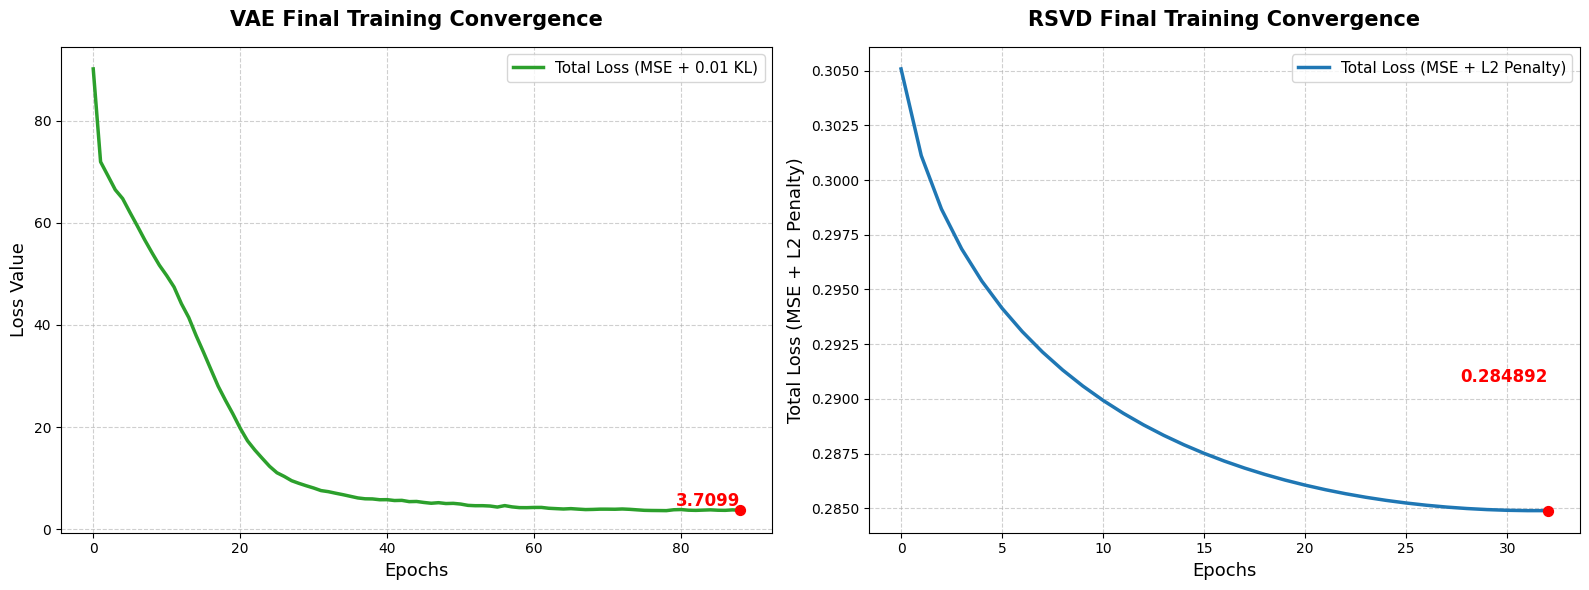

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
# ==========================================
# PLOT 1: KURVA LOSS VAE
# ==========================================
ax1 = axes[0]
# PERBAIKAN: Mengubah label menjadi (MSE + Beta KL) sesuai modifikasi fungsi loss di proposal
beta_val = best_vae_params.get('beta', 'β')
ax1.plot(vae_loss_history, label=f'Total Loss (MSE + {beta_val} KL)', color='#2ca02c', linewidth=2.5)

# Menandai titik epoch terakhir dengan scatter merah
vae_final_epoch = len(vae_loss_history) - 1
vae_final_loss = vae_loss_history[-1]
ax1.scatter(vae_final_epoch, vae_final_loss, color='red', s=50, zorder=5)
ax1.text(vae_final_epoch, vae_final_loss + (vae_final_loss * 0.02), f'{vae_final_loss:.4f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax1.set_title('VAE Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=13)
ax1.set_ylabel('Loss Value', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11)

# ==========================================
# PLOT 2: KURVA MSE RSVD
# ==========================================
ax2 = axes[1]
ax2.plot(rsvd_loss_history, label='Total Loss (MSE + L2 Penalty)', color='#1f77b4', linewidth=2.5)

# Menandai titik epoch terakhir dengan scatter merah
rsvd_final_epoch = len(rsvd_loss_history) - 1
rsvd_final_loss = rsvd_loss_history[-1]
ax2.scatter(rsvd_final_epoch, rsvd_final_loss, color='red', s=50, zorder=5)
ax2.text(rsvd_final_epoch, rsvd_final_loss + (rsvd_final_loss * 0.02), f'{rsvd_final_loss:.6f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax2.set_title('RSVD Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=13)
ax2.set_ylabel('Total Loss (MSE + L2 Penalty)', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11)

# ==========================================
# FINALISASI DAN PENYIMPANAN GAMBAR
# ==========================================
plt.tight_layout()

# Menyimpan gambar dengan resolusi tinggi (300 dpi) agar tajam saat dimasukkan ke PDF/Word Skripsi
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
plot_path = os.path.join(visualization_dir, f'final_training_curves_{timestamp}.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n[SUCCESS] Gambar grafik beresolusi tinggi (High-Res) berhasil disimpan di: {plot_path}")

plt.show()